# CoinGecko REST API: extracting crypto currency data

## Libraries and settings

In [1]:
# Libraries
import os
import locale
import warnings

import pandas as pd
import matplotlib.pyplot as plt
from pycoingecko import CoinGeckoAPI

# Ignore warnings
warnings.filterwarnings("ignore")

# Settings
locale.setlocale(locale.LC_ALL, "")

# Define settings for graphics
plt.style.use('dark_background')

cg = CoinGeckoAPI()

# Current working directory
print(f'Current working directory: {os.getcwd()}')

Current working directory: /workspaces/data_ingestion/03_CoinGecko_WebAPI


## Get data

In [2]:
# Simple price endpoint with the required parameters
cg.get_price(ids='bitcoin', vs_currencies='usd')

{'bitcoin': {'usd': 69360}}

In [3]:
# Multiple arguments (USD)
cg.get_price(
    ids=[
        'bitcoin',
        'near',
        'ethereum',
        'dogecoin'],
    vs_currencies='usd')

{'bitcoin': {'usd': 69357},
 'near': {'usd': 1.73},
 'ethereum': {'usd': 2247.21},
 'dogecoin': {'usd': 0.074647}}

In [4]:
# Multiple arguments (USD & EUR)
cg.get_price(
    ids=[
        'bitcoin',
        'near',
        'ethereum, dogecoin'],
    vs_currencies=[
        'usd',
        'eur'])

{'bitcoin': {'eur': 59428, 'usd': 69360},
 'near': {'eur': 1.48, 'usd': 1.73},
 'ethereum': {'eur': 1925.44, 'usd': 2247.21},
 'dogecoin': {'eur': 0.063958, 'usd': 0.074647}}

In [5]:
# Pass optional parameters as defined in the API doc
# (https://www.coingecko.com/api/docs/v3)
data = cg.get_price(ids='bitcoin, near, ethereum, dogecoin',
                    vs_currencies='usd',
                    include_market_cap='true',
                    include_24hr_vol='true',
                    include_24hr_change='true',
                    include_last_updated_at='true')
data

{'bitcoin': {'usd': 69359,
  'usd_market_cap': 1392145172842.8816,
  'usd_24h_vol': 50317295021.711945,
  'usd_24h_change': 8.032863513009268,
  'last_updated_at': 1787205580},
 'near': {'usd': 1.73,
  'usd_market_cap': 2252294728.357222,
  'usd_24h_vol': 209940368.79148164,
  'usd_24h_change': 7.806027071508494,
  'last_updated_at': 1787205560},
 'ethereum': {'usd': 2246.95,
  'usd_market_cap': 271165248601.2676,
  'usd_24h_vol': 31168239443.106384,
  'usd_24h_change': 17.69453596939759,
  'last_updated_at': 1787205580},
 'dogecoin': {'usd': 0.074635,
  'usd_market_cap': 11610479557.182156,
  'usd_24h_vol': 898292853.4456065,
  'usd_24h_change': 6.7480857454701715,
  'last_updated_at': 1787205560}}

In [6]:
# Extract single values
names = list(data.keys())
print(names)
print("----------------")

# Price of the first element in list
print(names[0])
print(data[names[0]]["usd"])

['bitcoin', 'near', 'ethereum', 'dogecoin']
----------------
bitcoin
69359


## Extract and plot data

In [7]:
# Keys from dictionary
names = list(data.keys())

# Get values from dictionary and format to 2 decimal places
values = []
for i in range(len(names)):
    vals = data[names[i]]["usd"]
    formatted_val = f'{vals:.2f}'
    values.append(formatted_val)

# Create DataFrame
df = pd.DataFrame({
    'Name': names,
    'Value': values})

# Convert 'Value' column to numeric
df['Value'] = pd.to_numeric(df['Value'])

# Sort DataFrame by 'Value' in descending order
df = df.sort_values(by='Value', ascending=False)

print(df)

       Name     Value
0   bitcoin  69359.00
2  ethereum   2246.95
1      near      1.73
3  dogecoin      0.07


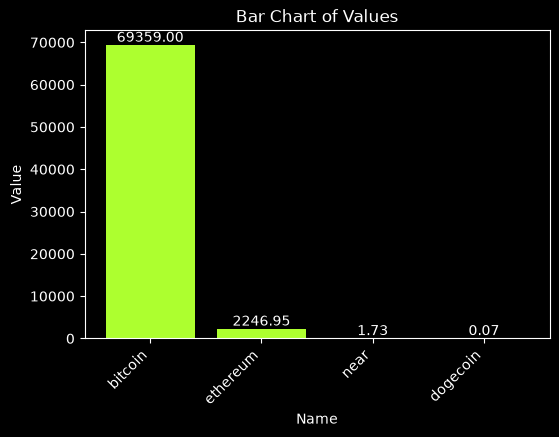

In [8]:
# Create bar chart
plt.figure(figsize=(6, 4))
bars = plt.bar(df['Name'], df['Value'], color='greenyellow')
plt.xlabel('Name')
plt.ylabel('Value')
plt.title('Bar Chart of Values')
plt.xticks(rotation=45, ha='right')

# Add values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             yval + 0.05, f'{yval:.2f}',
             ha='center',
             va='bottom')
plt.show()

### Jupyter notebook --footer info-- (please always provide this at the end of each notebook)

In [9]:
import os
import platform
import socket
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
POSIX
Linux | 6.8.0-1052-azure
Datetime: 2026-08-20 06:01:04
Python Version: 3.12.13
-----------------------------------
